# Data Matrix ROI overview

One row per photo in `images/` (sorted by name). Detection and cropping come from **`dm_roi.py`** in this folder (imported, not duplicated).

Assumptions used by the detector:
* codes are **square** Data Matrix symbols (no rectangular variants);
* coarse orientation in **90° steps** (0 / 90 / 180 / 270, from the L finder when it can be verified);
* up to about **±10° tilt** around each step (`max_tilt_deg`, configurable), so there's no arbitrary-angle search.

Columns: the input thumbnail with ROI outlines (green = primary, orange = other candidates), the **primary crop** (padded, deskewed, rotated so the L finder is at left + bottom when known), then up to 3 more candidate crops. Each crop shows the estimated **pixels per module** (module pitch in ORIGINAL full-resolution pixels, plus the grid size N×N when known). The same value is repeated in the caption next to score, rotation and tilt. Decoding is out of scope.

In [1]:
# ---- configuration -------------------------------------------------------
from pathlib import Path

IMAGE_DIR = Path("images")          # input photos (read-only)
HTML_OUT = Path("dm_roi_overview.html")
THUMB_SIZE = 240                     # long side of the input thumbnail (px)
CROP_PAD = 0.2                       # padding around the code (fraction of its side)
CROP_SIZE = 200                      # crop display size (px)
MAX_CANDIDATES = 4                   # primary + up to 3 more candidates
DM_PARAMS = dict(                    # forwarded to dm_roi.find_dm_rois (DMConfig fields)
    max_tilt_deg=10.0,
    min_score=0.55,
    work_long_side=1600,
)

In [2]:
import sys, time, base64, html, statistics
import cv2
import numpy as np
import pandas as pd
from IPython.display import HTML, display

sys.path.insert(0, str(Path.cwd()))   # dm_roi.py lives next to this notebook
import dm_roi

def png_b64(img_bgr):
    ok, buf = cv2.imencode(".png", img_bgr)
    return base64.b64encode(buf.tobytes()).decode("ascii")

def img_tag(img_bgr, width=None):
    w = f' width="{width}"' if width else ""
    return f'<img src="data:image/png;base64,{png_b64(img_bgr)}"{w}/>'

def caption(r):
    rot = "?" if r.rotation is None else f"{r.rotation}"
    mod = "n/a" if r.module_px is None else f"{r.module_px:.1f} px/mod"
    if r.module_px is not None and r.grid_n:
        mod += f" ({r.grid_n}×{r.grid_n})"
    return f"score {r.score:.2f} · rot {rot} · tilt {r.tilt_deg:+.1f}° · {mod}"

print("dm_roi from", dm_roi.__file__)

dm_roi from /workspace/dmroi/nb_work/dm_roi.py


In [3]:
files = sorted(p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in dm_roi.IMAGE_EXTENSIONS)
rows, n_det, module_vals = [], [], []
t_start = time.perf_counter()
for p in files:
    img = dm_roi.load_image(p)                         # full res (pillow-heif), freed below
    rois = dm_roi.find_dm_rois(img, max_results=MAX_CANDIDATES, **DM_PARAMS)
    thumb = dm_roi.draw_rois(img, rois, max_long_side=THUMB_SIZE, labels=False, thickness=2)
    cells = []
    for r in rois:
        crop = dm_roi.crop_roi(img, r, pad=CROP_PAD, deskew=True, out_size=CROP_SIZE, annotate=True)
        cells.append(f'{img_tag(crop)}<br><span class="cap">{html.escape(caption(r))}</span>')
        if r.module_px is not None:
            module_vals.append(r.module_px)
    del img                                             # keep memory low across 65 x 12 MP
    cells += [""] * (MAX_CANDIDATES - len(cells))
    row = {"Image": f'{img_tag(thumb)}<br><span class="cap">{html.escape(p.name)} · {len(rois)} ROI(s)</span>',
           "Primary ROI": cells[0] if rois else '<span class="cap">no Data Matrix found</span>'}
    for i in range(1, MAX_CANDIDATES):
        row[f"Candidate {i + 1}"] = cells[i]
    rows.append(row)
    n_det.append(len(rois))
elapsed = time.perf_counter() - t_start
df = pd.DataFrame(rows)
n0 = sum(1 for n in n_det if n == 0); n1 = sum(1 for n in n_det if n == 1); n2 = sum(1 for n in n_det if n >= 2)
summary = (f"{len(files)} images in {elapsed:.1f} s ({elapsed / max(1, len(files)):.2f} s/image): "
           f"{n0} with 0 detections, {n1} with 1, {n2} with 2+ (total {sum(n_det)} ROIs).")
if module_vals:
    summary += (f" px/module across detections: min {min(module_vals):.1f}, "
                f"median {statistics.median(module_vals):.1f}, max {max(module_vals):.1f}.")
print(summary)

65 images in 131.7 s (2.03 s/image): 2 with 0 detections, 46 with 1, 17 with 2+ (total 85 ROIs). px/module across detections: min 14.7, median 26.8, max 69.1.


saved /workspace/dmroi/nb_work/dm_roi_overview.html


Image,Primary ROI,Candidate 2,Candidate 3,Candidate 4
IMG_0034.HEIC · 1 ROI(s),score 0.90 · rot 0 · tilt -0.3° · 26.1 px/mod (20×20),,,
IMG_0035.HEIC · 1 ROI(s),score 0.89 · rot 0 · tilt +0.4° · 22.6 px/mod (20×20),,,
IMG_0036.HEIC · 1 ROI(s),score 0.89 · rot 90 · tilt -0.3° · 23.6 px/mod (20×20),,,
IMG_0037.HEIC · 2 ROI(s),score 0.92 · rot 90 · tilt +0.1° · 23.0 px/mod (14×14),score 0.87 · rot 90 · tilt +0.1° · 24.2 px/mod (14×14),,
IMG_0038.HEIC · 2 ROI(s),score 0.91 · rot 90 · tilt +0.1° · 22.7 px/mod (14×14),score 0.88 · rot 90 · tilt -0.4° · 24.0 px/mod (14×14),,
IMG_0039.HEIC · 2 ROI(s),score 0.93 · rot 90 · tilt -0.7° · 22.4 px/mod (14×14),score 0.87 · rot 90 · tilt -0.7° · 24.2 px/mod (14×14),,
IMG_0040.HEIC · 2 ROI(s),score 0.92 · rot 90 · tilt -0.6° · 22.7 px/mod (14×14),score 0.88 · rot 90 · tilt -0.5° · 24.2 px/mod (14×14),,
IMG_0041.HEIC · 1 ROI(s),score 0.92 · rot 90 · tilt -0.1° · 17.5 px/mod (26×26),,,
IMG_0042.HEIC · 1 ROI(s),score 0.90 · rot 90 · tilt -0.2° · 17.3 px/mod (26×26),,,
IMG_0043.HEIC · 1 ROI(s),score 0.97 · rot ? · tilt -0.5° · 26.7 px/mod (22×22),,,

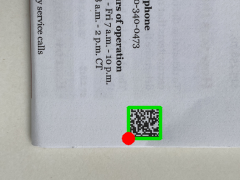
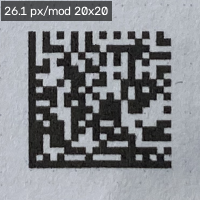
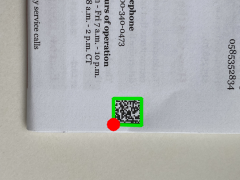
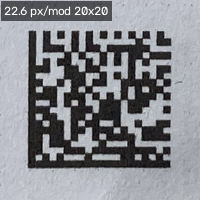
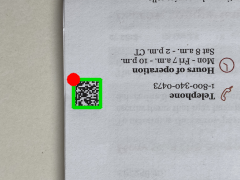
...
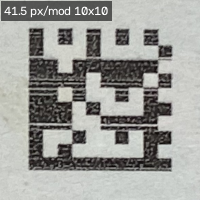
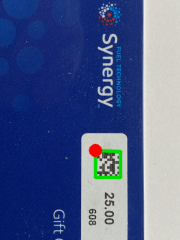
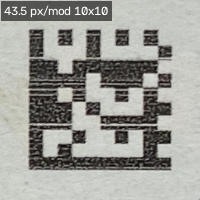
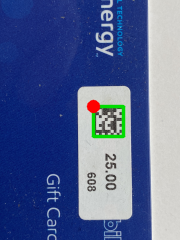
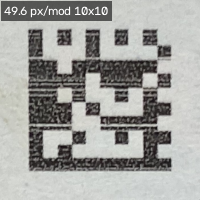

In [4]:
style = """<style>
table.dmtab {border-collapse: collapse; font-family: sans-serif;}
table.dmtab td, table.dmtab th {border: 1px solid #ccc; padding: 4px; vertical-align: top; text-align: center;}
table.dmtab th {background: #eee;}
.cap {font-size: 11px; color: #333;}
</style>"""
table_html = df.to_html(escape=False, index=False, classes="dmtab", border=0)
page = (f"<!DOCTYPE html><html><head><meta charset='utf-8'><title>DM ROI overview</title>{style}</head>"
        f"<body><h2>Data Matrix ROI overview</h2><p>{html.escape(summary)}</p>{table_html}</body></html>")
HTML_OUT.write_text(page, encoding="utf-8")
print("saved", HTML_OUT.resolve())
display(HTML(style + f"<p>{html.escape(summary)}</p>" + table_html))